In [1]:
import numpy as np
import matplotlib.pyplot as plt

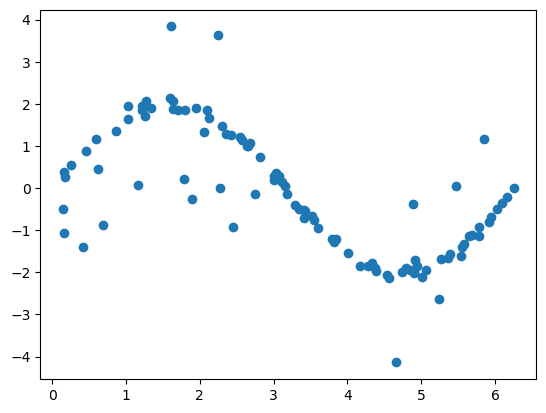

In [2]:
m=100
x = 2*np.pi*np.random.rand(m)
y = 2*np.sin(x) +0.1*np.random.randn(m)
# every 5 data points, we add an "outlier"
n = m//5
y[::5]+=5*(0.5-np.random.rand(m//5))


plt.scatter(x,y)


In [3]:
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth =4)
tree.fit(x.reshape(-1,1),y) # needs column vector

DecisionTreeRegressor(max_depth=4)

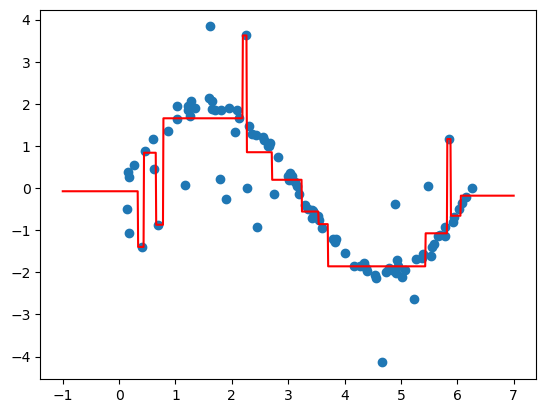

In [4]:
x_plot = np.linspace(-1,7,1000).reshape(-1,1)
y_plot = tree.predict(x_plot)
plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')

Remark 1: trees are very sensitive to outliers

Remark 2: trees are very bad at extrapolating outside of the range of test information

In [5]:
from sklearn.ensemble import RandomForestRegressor

In [6]:
rf = RandomForestRegressor(max_depth=3,n_estimators=200)
rf.fit(x.reshape(-1,1),y)

RandomForestRegressor(max_depth=3, n_estimators=200)

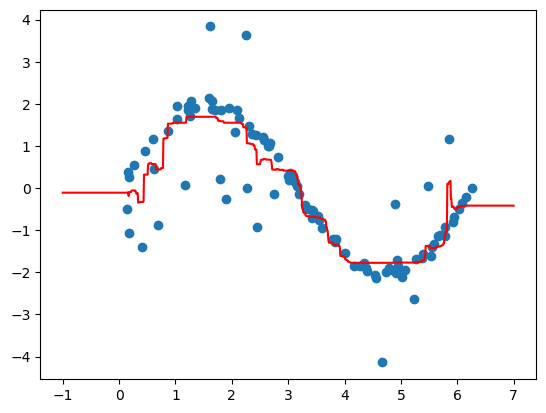

In [7]:
x_plot = np.linspace(-1,7,1000).reshape(-1,1)
y_plot = rf.predict(x_plot)
plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')

## Fremont Bridge Revisited

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [9]:
# load bike traffic and weather data 
fremont = pd.read_csv('Fremont_Bridge_Bicycle_Counter.csv',index_col='Date',parse_dates=True)
fremont.columns = ['total','east','west'] # rename columns
weather = pd.read_csv('weather.csv',index_col='DATE',parse_dates=True)

# compute daily traffic
fremont = fremont.resample('d').sum()

# day of the week/month/year/covid
fremont['day_of_week'] = fremont.index.dayofweek
fremont['month'] = fremont.index.month
fremont['year'] = fremont.index.year
# covid column: 0 = pre covid times; 1 = pos covid times
fremont['covid'] = 0
fremont.loc['03-01-2020':,'covid'] = 1 

# holidays
from pandas.tseries.holiday import USFederalHolidayCalendar
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays('10-03-2012','08-31-2023')
fremont['holidays'] = pd.Series(1,index=holidays,name='holidays')
fremont.fillna(0,inplace=True)

# hours of daylight
def get_hoursdaylight(date):
    axis = np.radians(23.44) # tilt of Earth's axis
    latitude = np.radians(47.61) # Seattle's latidude 
    days = (date-pd.to_datetime('2000-12-31')).days
    m = (1 - np.tan(latitude)*np.tan(axis*np.cos(days*2*np.pi/365.25)))
    return 24*np.degrees(np.arccos(1-m))/180
fremont['hours_daylight'] = fremont.index.map(get_hoursdaylight)

# fix TAVG column
weather.TAVG.fillna(0.5*(weather.TMAX+weather.TMIN),inplace=True)

# add weather columns
fremont['PRCP'] = weather.PRCP
fremont['TAVG'] = weather.TAVG
fremont['SNOW'] = weather.SNOW
fremont['AWND'] = weather.AWND

fremont

,total,east,west,day_of_week,month,year,covid,holidays,hours_daylight,PRCP,TAVG,SNOW,AWND
Date,,,,,,,,,,,,,
2012-10-03,3521.0,1760.0,1761.0,2,10,2012,0,0.0,11.863813,0.00,56.0,0.0,16.33
2012-10-04,3475.0,1708.0,1767.0,3,10,2012,0,0.0,11.804946,0.00,56.5,0.0,14.54
2012-10-05,3148.0,1558.0,1590.0,4,10,2012,0,0.0,11.746107,0.00,59.5,0.0,12.75
2012-10-06,2006.0,1080.0,926.0,5,10,2012,0,0.0,11.687302,0.00,60.5,0.0,11.41
2012-10-07,2142.0,1191.0,951.0,6,10,2012,0,0.0,11.628541,0.00,60.5,0.0,2.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-27,2169.0,936.0,1233.0,6,8,2023,1,0.0,14.020464,0.00,72.0,0.0,6.26
2023-08-28,3027.0,1026.0,2001.0,0,8,2023,1,0.0,13.967394,0.00,66.0,0.0,6.71
2023-08-29,2767.0,842.0,1925.0,1,8,2023,1,0.0,13.913949,0.12,61.0,0.0,6.49


In [10]:


from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, PolynomialFeatures



In [11]:


# regression pipeline

num_features = ['hours_daylight','year','PRCP','TAVG','SNOW','AWND','covid','holidays']
cat_features = ['day_of_week']


num_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
    ])

cat_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
    ])



feature_processor = ColumnTransformer(transformers=[
    ('num_processor',num_processor,num_features),
    ('cat_processor',cat_processor, cat_features),
])

pipe = Pipeline(steps=[
    ('feature_processor',feature_processor),
    ('poly_features',PolynomialFeatures(degree=2)),
    ('reg',LinearRegression())
])

pipe



Pipeline(steps=[('feature_processor',
                 ColumnTransformer(transformers=[('num_processor',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['hours_daylight', 'year',
                                                   'PRCP', 'TAVG', 'SNOW',
                                                   'AWND', 'covid',
                                                   'holidays']),
                                                 ('cat_processor',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['day_of_week'])])),
                ('poly_features', PolynomialFeatures()),
                ('reg', LinearRegression())])

In [12]:
fremont.columns

Index(['total', 'east', 'west', 'day_of_week', 'month', 'year', 'covid',
       'holidays', 'hours_daylight', 'PRCP', 'TAVG', 'SNOW', 'AWND'],
      dtype='object')

In [13]:
y = fremont.total
X = fremont[num_features+cat_features]

In [14]:
pipe.fit(X,y)
fremont['predictions_lin_reg'] = pipe.predict(X)

In [15]:
# random forest pipeline
pipe = Pipeline(steps=[
    ('feature_processor',feature_processor),
    #('poly_features',PolynomialFeatures(degree=2)),
    ('reg',RandomForestRegressor())
])

In [16]:
pipe

Pipeline(steps=[('feature_processor',
                 ColumnTransformer(transformers=[('num_processor',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['hours_daylight', 'year',
                                                   'PRCP', 'TAVG', 'SNOW',
                                                   'AWND', 'covid',
                                                   'holidays']),
                                                 ('cat_processor',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['day_of_week'])])),
                ('reg', RandomForestRegressor())])

In [21]:
param_dict = {'reg__n_estimators':[50,100,200,500],
            'reg__max_depth':[2,5,10],
            'reg__min_samples_split':[2,4,8,16,32],
            'reg__min_samples_leaf':[1,2,4,8,16,32],
            'reg__max_leaf_nodes': [None]# none=unlimited
            }

In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:
grid = GridSearchCV(pipe, param_dict, cv=5, n_jobs=-1)

In [24]:
grid.fit(X,y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_processor',
                                        ColumnTransformer(transformers=[('num_processor',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['hours_daylight',
                                                                          'year',
                                                                          'PRCP',
                                                                          'TAVG',
                                                                          'SNOW',
                                                                          'AWND',
                                                                          'covid',
                                                                          'holidays']),
                                                                        ('cat_processor',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder())]),
                                                                         ['day_of_week'])])),
                                       ('reg', RandomForestRegressor())]),
             n_jobs=-1,
             param_grid={'reg__max_depth': [2, 5, 10],
                         'reg__max_leaf_nodes': [None],
                         'reg__min_samples_leaf': [1, 2, 4, 8, 16, 32],
                         'reg__min_samples_split': [2, 4, 8, 16, 32],
                         'reg__n_estimators': [50, 100, 200, 500]})

In [25]:
best_pipe = grid.best_estimator_
fremont['predictions_rf'] = best_pipe.predict(X)

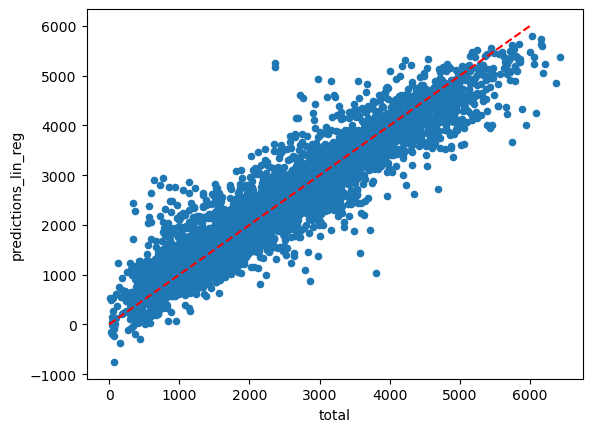

In [26]:
fremont.plot.scatter(x='total', y = 'predictions_lin_reg')
plt.plot([0,6000], [0,6000], 'r--')

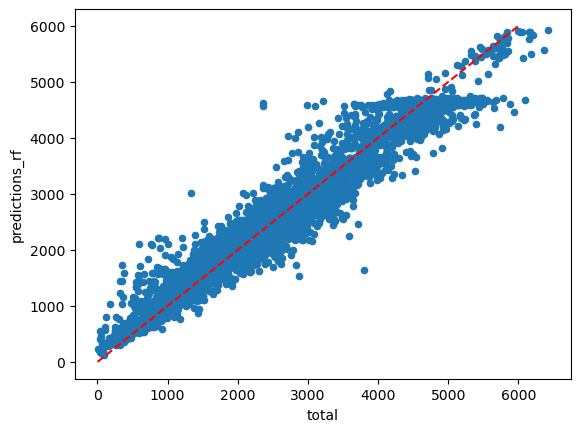

In [27]:
fremont.plot.scatter(x='total', y = 'predictions_rf')
plt.plot([0,6000], [0,6000], 'r--')

<AxesSubplot:xlabel='Date'>

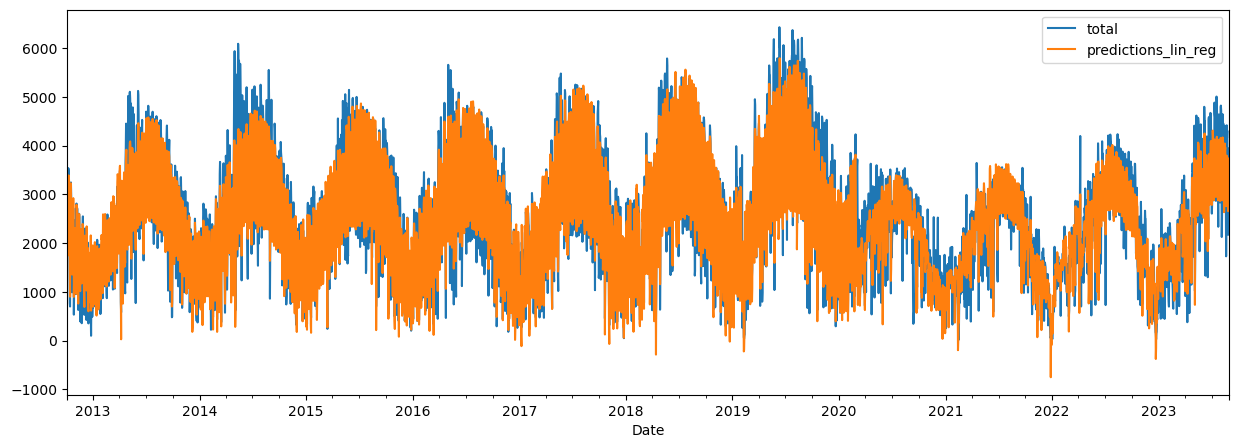

In [28]:
fremont[['total', 'predictions_lin_reg']].plot(figsize=(15,5))

<AxesSubplot:xlabel='Date'>

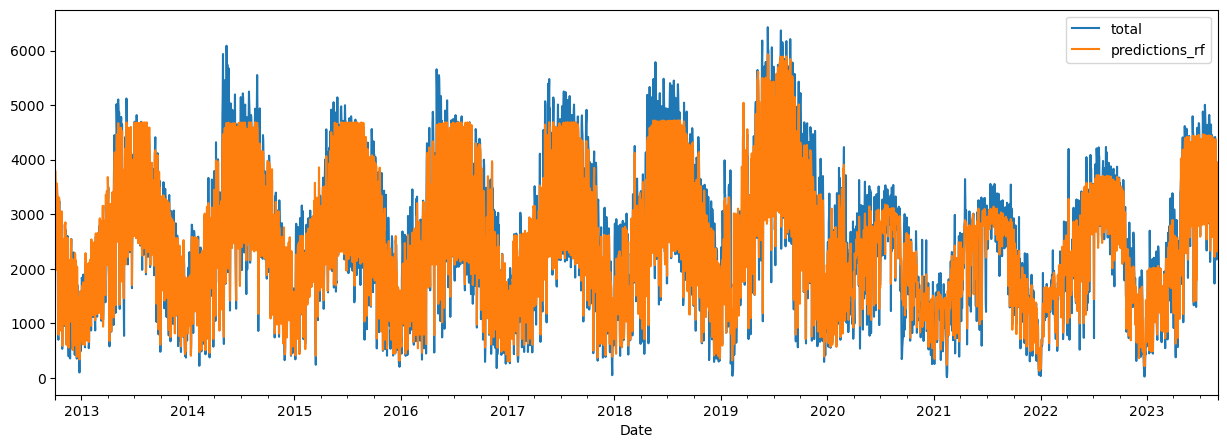

In [30]:
# random forest
fremont[['total','predictions_rf']].plot(figsize=(15,5))